# QC: session coverage for the LDA-1 neural analyses (`lda_pids`)
Before touching the neuron/firing-rate files themselves, sanity-check the trial coverage of the
sessions that feed the LDA-1 neural analyses (`ff_psth_ldabin.ipynb`, `noise_corr_psth_lda.ipynb`,
`fr_psth_ldabin.ipynb`, `neural_spike_files.ipynb`).

`lda_pids` = the probe-insertion IDs (`pid`) for every brain-wide-map (BWM) session whose `eid` is
present in the LDA-1 clustering table (`mouse_LDA_5_bins_cut*`) -- same construction as
`neural_spike_files.ipynb`'s `lda_pid`. A session can have more than one probe, so `len(lda_pids) >
len(lda_eids)`.

This first QC pass only needs trial-level behavioral metadata (already available locally in
`session_trial_meta_10-07-2026`), not the neuron spike-count files -- no need to load those yet.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import brainwidemap
from one.api import ONE

warnings_ = None
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid'); plt.rcParams['figure.facecolor'] = 'white'

one = ONE()

In [2]:
prefix = '/home/ines/repositories/representation_learning_variability/paper-individuality/'
prefix = '/Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/'
clustering_dir = prefix + 'clustering/'
data_dir = prefix + 'data/'

## Build `lda_eids` / `lda_pids` (same construction as `neural_spike_files.ipynb`)

In [3]:
LDA_FILE = 'mouse_LDA_5_bins_cut19-06-2026'   # 'mouse_LDA_5_bins_cut06-07-2026' referenced elsewhere isn't on this machine

lda = pd.read_pickle(clustering_dir + LDA_FILE)
bwm_df = brainwidemap.bwm_query()   # BWM release table: one row per probe insertion (pid)

lda_eids = lda.loc[lda['session'].isin(bwm_df['eid']), 'session'].unique()
lda_pids = bwm_df.loc[bwm_df['eid'].isin(lda_eids), 'pid'].unique()

print(f"LDA-1 table: {lda['session'].nunique()} sessions")
print(f"  of which in the BWM release (lda_eids): {len(lda_eids)} sessions")
print(f"  -> lda_pids: {len(lda_pids)} probe insertions (some sessions have >1 probe)")

Loading bwm_query results from fixtures/2023_12_bwm_release.csv
LDA-1 table: 248 sessions
  of which in the BWM release (lda_eids): 244 sessions
  -> lda_pids: 380 probe insertions (some sessions have >1 probe)


## Trials per session (lda_eids only)
Trial counts come straight from the trial-metadata table already computed locally
(`session_trial_meta_10-07-2026`) -- this is pure behavioral/ONE trial data, so there's no need to
touch the (currently un-synced locally) per-pid neuron/firing-rate files for this check.

In [4]:
trial_meta_file = data_dir + 'session_trial_meta_10-07-2026'
trials_df = pd.read_parquet(trial_meta_file)

n_trials_per_session = trials_df.groupby('session')['trial_id'].nunique()
n_trials_lda = n_trials_per_session.reindex(lda_eids)

missing = n_trials_lda[n_trials_lda.isna()].index.tolist()
n_trials_lda = n_trials_lda.dropna()
print(f"Trial-count coverage: {len(n_trials_lda)}/{len(lda_eids)} lda_eids found in {trial_meta_file.split('/')[-1]}")
if missing:
    print(f"  {len(missing)} lda_eids missing from the trial-meta table, e.g. {missing[:5]}")

Trial-count coverage: 244/244 lda_eids found in session_trial_meta_10-07-2026


KeyboardInterrupt: 

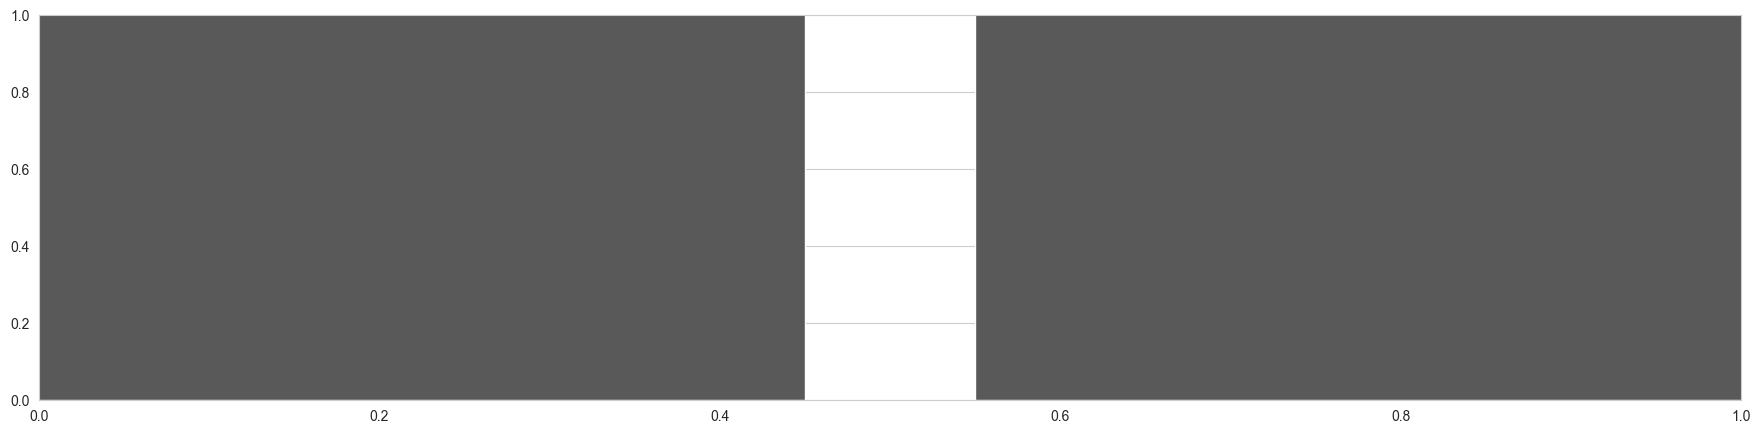

In [5]:
MIN_TRIALS = 400   # same order of magnitude as MIN_TRIALS/SESSION_N_TARGET used in the FF/r_SC notebooks

order = n_trials_lda.sort_values(ascending=False)
below = order[order < MIN_TRIALS]

fig, ax = plt.subplots(figsize=(max(8, len(order) * 0.09), 5))
colors = ['crimson' if v < MIN_TRIALS else '0.35' for v in order.values]
ax.bar(np.arange(len(order)), order.values, color=colors, width=0.9)
ax.axhline(MIN_TRIALS, color='crimson', ls='--', lw=1.2, alpha=0.8,
           label=f'{MIN_TRIALS} trials ({len(below)} sessions below)')
ax.set_xlabel('Session (sorted by trial count)')
ax.set_ylabel('Number of trials')
ax.set_title(f'Trials per session -- lda_eids (n={len(order)} sessions, {len(lda_pids)} pids)')
ax.set_xticks([])
ax.legend(fontsize=9)
sns.despine(ax=ax, offset=4)
plt.tight_layout(); plt.show()

print(order.describe())
print(f"\n{len(below)} session(s) below {MIN_TRIALS} trials:")
print(below)

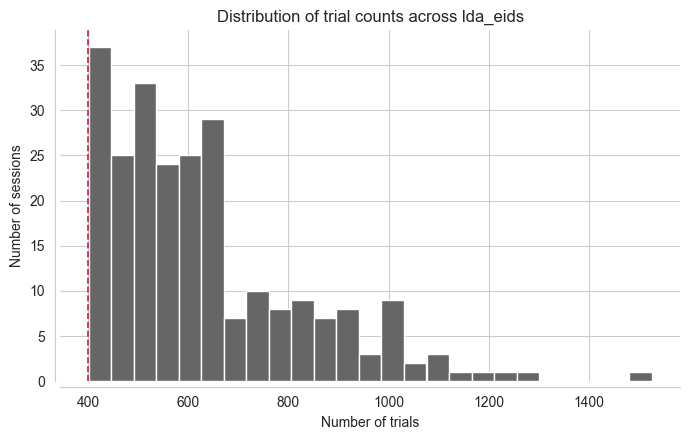

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(n_trials_lda.values, bins=25, color='0.4', edgecolor='white')
ax.axvline(MIN_TRIALS, color='crimson', ls='--', lw=1.2)
ax.set_xlabel('Number of trials'); ax.set_ylabel('Number of sessions')
ax.set_title('Distribution of trial counts across lda_eids')
sns.despine(ax=ax, offset=4)
plt.tight_layout(); plt.show()

## Region / neuron-count / firing-rate QC (random sample of `lda_pids`)
The full `neuron_files` data lives on Google Drive (`My Drive/CCU/PhD project/paper-individuality/`
`data/neuron_files/states_neurons_file_<pid>`), one file per pid, matching `lda_pids` 1:1 (380
files). Each file is a full-session, ~60 Hz spike-count table per neuron (~270 MB/file, ~100 GB for
all 380) -- too much to read in full for a first QC pass, so this reads a **random sample of 30
pids** (seed=0) instead. Numbers below are therefore *estimates* from that sample, not exhaustive
counts across all 380 sessions -- a rare region could be under- or over-represented by chance.

Each neuron's column is labelled `<area>_neuron_<cluster_id>_spike_count`; `<area>` is mapped to its
Beryl-level acronym. Note: the same cluster id can appear under more than one area label (its own
area and an ancestor area) due to how `neural_spike_files.ipynb` selects "descendants" per unique
atlas_id -- the sampling script keeps only the first-seen label per cluster id per file and logs how
often this happens (see `qc_neuron_region_sample.log`).

In [ ]:
import os, re, gc, time
import brainwidemap
from iblatlas.regions import BrainRegions

GD_DIR = ("/Users/ineslaranjeira/Library/CloudStorage/"
          "GoogleDrive-ines.laranjeira@research.fchampalimaud.org/O meu disco/"
          "CCU/PhD project/paper-individuality/data/neuron_files")
neuron_sample_file = prefix + 'neural/qc/qc_neuron_region_sample.csv'
N_SAMPLE = 30

if os.path.exists(neuron_sample_file):
    # Re-reading straight from GD_DIR takes ~40+ min cold the first time (network transfer of
    # ~270 MB/file), so cache to disk and only regenerate if the cache is missing or N_SAMPLE changes.
    neuron_sample = pd.read_csv(neuron_sample_file)
    print(f"Loaded cached sample from {neuron_sample_file}")
else:
    br_qc = BrainRegions()
    _beryl_cache = {}
    def to_beryl(acronym):
        if acronym in _beryl_cache:
            return _beryl_cache[acronym]
        try:
            b = br_qc.acronym2acronym([acronym], mapping='Beryl')[0]
        except Exception:
            b = None
        _beryl_cache[acronym] = b
        return b

    bwm_df_qc = brainwidemap.bwm_query()
    lda_pids_df = bwm_df_qc.loc[bwm_df_qc['eid'].isin(lda_eids), ['pid', 'eid']].drop_duplicates()
    pid_to_eid = dict(zip(lda_pids_df['pid'], lda_pids_df['eid']))
    rng_qc = np.random.default_rng(SEED)
    sample_pids = rng_qc.choice(lda_pids_df['pid'].tolist(), size=min(N_SAMPLE, len(lda_pids_df)),
                                 replace=False).tolist()

    col_re = re.compile(r'^(.+)_neuron_(\d+)_spike_count$')
    records, dup_count = [], 0
    t_start = time.time()
    for i, pid in enumerate(sample_pids):
        fn = os.path.join(GD_DIR, f"states_neurons_file_{pid}")
        if not os.path.exists(fn):
            print(f"[{i+1}/{len(sample_pids)}] MISSING file for pid {pid}"); continue
        t0 = time.time()
        df_n = pd.read_pickle(fn)   # ~270 MB, one file per probe insertion; slow the first time,
                                     # fast (~0.2s) once Google Drive has it cached locally
        eid = pid_to_eid.get(pid)
        bin_width = df_n['Bin'].diff().median()
        duration_s = len(df_n) * bin_width
        spike_cols = [c for c in df_n.columns if c.endswith('spike_count')]
        seen_cluster = {}
        for c in spike_cols:
            m = col_re.match(c)
            if not m: continue
            raw_area, cid = m.group(1), int(m.group(2))
            if cid in seen_cluster:
                dup_count += 1
                continue  # keep first-seen area label per cluster id (see markdown above)
            seen_cluster[cid] = raw_area
            fr_hz = df_n[c].sum() / duration_s if duration_s > 0 else np.nan
            records.append(dict(pid=pid, eid=eid, cluster_id=cid, raw_area=raw_area,
                                 beryl_region=to_beryl(raw_area), mean_fr_hz=fr_hz, n_rows=len(df_n)))
        del df_n; gc.collect()
        print(f"[{i+1}/{len(sample_pids)}] pid={pid} load={time.time()-t0:.1f}s "
              f"neurons={len(seen_cluster)} dup_so_far={dup_count} "
              f"elapsed_total={(time.time()-t_start)/60:.1f}min")

    neuron_sample = pd.DataFrame(records)
    neuron_sample.to_csv(neuron_sample_file, index=False)
    print(f"Saved {len(neuron_sample)} neuron rows to {neuron_sample_file}; "
          f"{dup_count} duplicate cluster-area occurrences skipped")

neuron_sample['eid'] = neuron_sample['eid'].astype(str)
print(f"{len(neuron_sample)} neuron rows | {neuron_sample['pid'].nunique()} pids | "
      f"{neuron_sample['eid'].nunique()} sessions | {neuron_sample['beryl_region'].nunique()} beryl regions")
neuron_sample.head()

Loaded cached sample from /Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/neural/qc/qc_neuron_region_sample.csv
2747 neuron rows | 30 pids | 30 sessions | 79 beryl regions


,pid,eid,cluster_id,raw_area,beryl_region,mean_fr_hz,n_rows
0,f4f45cff-c45c-413a-92ea-b6533e3e0019,e49d8ee7-24b9-416a-9d04-9be33b655f40,20,PIR,PIR,1.427286,168908
1,f4f45cff-c45c-413a-92ea-b6533e3e0019,e49d8ee7-24b9-416a-9d04-9be33b655f40,27,PIR,PIR,2.120681,168908
2,f4f45cff-c45c-413a-92ea-b6533e3e0019,e49d8ee7-24b9-416a-9d04-9be33b655f40,32,PIR,PIR,9.160490,168908
3,f4f45cff-c45c-413a-92ea-b6533e3e0019,e49d8ee7-24b9-416a-9d04-9be33b655f40,41,PIR,PIR,4.052028,168908
4,f4f45cff-c45c-413a-92ea-b6533e3e0019,e49d8ee7-24b9-416a-9d04-9be33b655f40,44,PIR,PIR,1.791389,168908


### 1) Beryl region coverage -- regions present in too few sessions
For each Beryl region, count the number of *sessions* (eids) in the sample where at least one
neuron was recorded in that region.

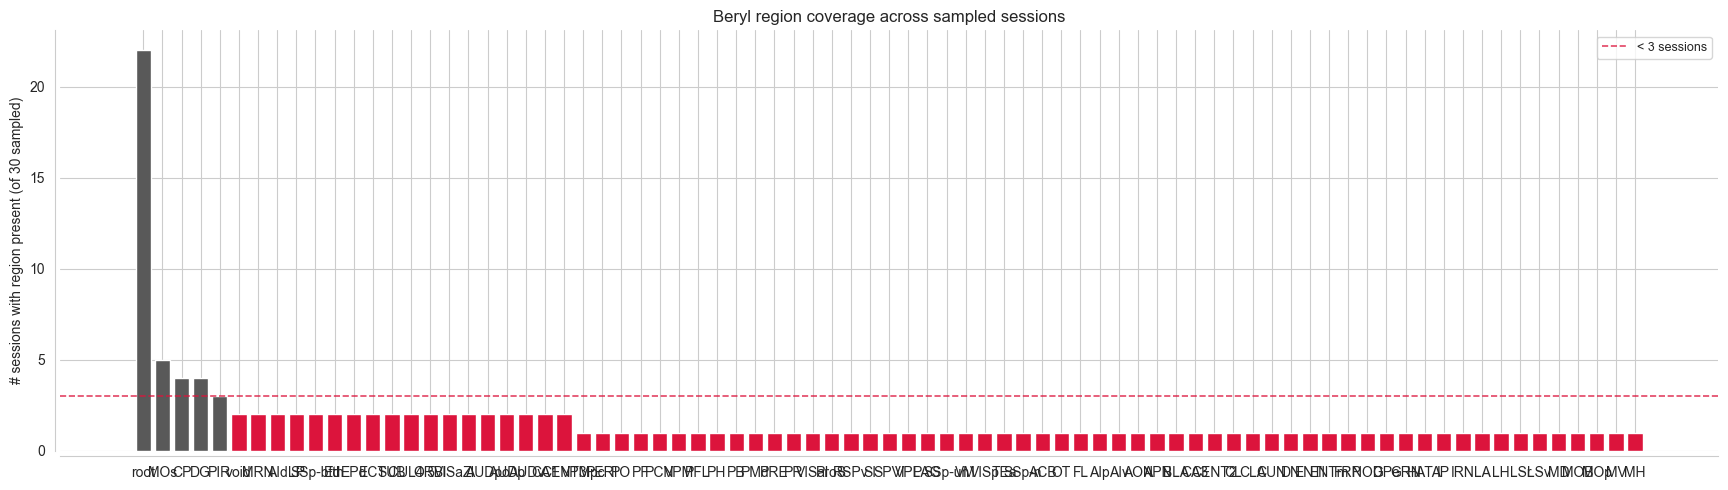

74/79 regions appear in < 3 sampled sessions:
beryl_region
void       2
MRN        2
AId        2
LP         2
SSp-bfd    2
          ..
MD         1
MOB        1
MOp        1
MV         1
MH         1
Name: eid, Length: 74, dtype: int64


In [ ]:
MIN_SESSIONS_PER_REGION = 3   # flag regions seen in fewer sampled sessions than this

sessions_per_region = (neuron_sample.dropna(subset=['beryl_region'])
                        .groupby('beryl_region')['eid'].nunique()
                        .sort_values(ascending=False))
n_sampled_sessions = neuron_sample['eid'].nunique()

fig, ax = plt.subplots(figsize=(max(8, len(sessions_per_region) * 0.22), 5))
colors = ['crimson' if v < MIN_SESSIONS_PER_REGION else '0.35' for v in sessions_per_region.values]
ax.bar(np.arange(len(sessions_per_region)), sessions_per_region.values, color=colors)
ax.axhline(MIN_SESSIONS_PER_REGION, color='crimson', ls='--', lw=1.2, alpha=0.8,
           label=f'< {MIN_SESSIONS_PER_REGION} sessions')
ax.set_xticks(np.arange(len(sessions_per_region)))
ax.set_xticklabels(sessions_per_region.index, rotation=90, fontsize=7)
ax.set_ylabel(f'# sessions with region present (of {n_sampled_sessions} sampled)')
ax.set_title('Beryl region coverage across sampled sessions')
ax.legend(fontsize=9); sns.despine(ax=ax, offset=4)
plt.tight_layout(); plt.show()

low_coverage = sessions_per_region[sessions_per_region < MIN_SESSIONS_PER_REGION]
print(f"{len(low_coverage)}/{len(sessions_per_region)} regions appear in < {MIN_SESSIONS_PER_REGION} "
      f"sampled sessions:")
print(low_coverage)

### 2) Regions with too few neurons per session
For each (session, region) pair, count the number of (deduplicated) neurons. Compare against
`MIN_NEURONS = 15`, the same cutoff `ff_psth_ldabin.ipynb` / `noise_corr_psth_lda.ipynb` use to admit
a session-region into their analyses.

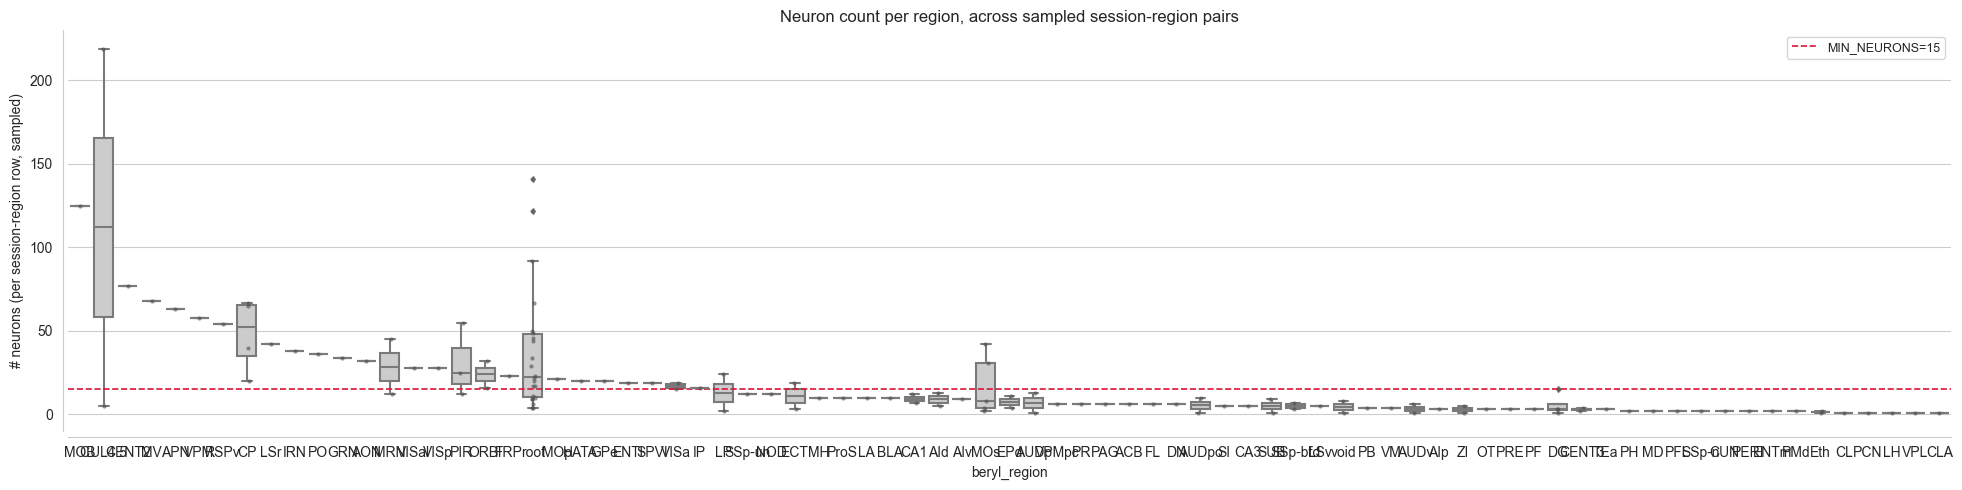

Fraction of sampled session-region rows below MIN_NEURONS=15, by region (1.0 = always below):
beryl_region
ACB    1.0
PMd    1.0
LSv    1.0
MD     1.0
AId    1.0
      ... 
LSr    0.0
GPe    0.0
GRN    0.0
IRN    0.0
CP     0.0
Name: n_neurons, Length: 79, dtype: float64


In [ ]:
MIN_NEURONS = 15

neurons_per_session_region = (neuron_sample.dropna(subset=['beryl_region'])
                               .groupby(['eid', 'beryl_region'])['cluster_id'].nunique()
                               .rename('n_neurons').reset_index())

region_order = (neurons_per_session_region.groupby('beryl_region')['n_neurons'].median()
                .sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(max(8, len(region_order) * 0.25), 5))
sns.boxplot(data=neurons_per_session_region, x='beryl_region', y='n_neurons', order=region_order,
            ax=ax, color='0.8', fliersize=3)
sns.stripplot(data=neurons_per_session_region, x='beryl_region', y='n_neurons', order=region_order,
              ax=ax, color='0.3', size=3, alpha=0.6)
ax.axhline(MIN_NEURONS, color='crimson', ls='--', lw=1.2, label=f'MIN_NEURONS={MIN_NEURONS}')
ax.set_xticklabels(region_order, rotation=90, fontsize=7)
ax.set_ylabel('# neurons (per session-region row, sampled)')
ax.set_title('Neuron count per region, across sampled session-region pairs')
ax.legend(fontsize=9); sns.despine(ax=ax, offset=4)
plt.tight_layout(); plt.show()

frac_below = (neurons_per_session_region.groupby('beryl_region')['n_neurons']
              .apply(lambda s: (s < MIN_NEURONS).mean()).sort_values(ascending=False))
print(f"Fraction of sampled session-region rows below MIN_NEURONS={MIN_NEURONS}, by region "
      f"(1.0 = always below):")
print(frac_below)

### 3) Fraction of neurons with too low a firing rate
Per-neuron mean firing rate = total spike count / (n_bins x median bin width), over the in-trial
bins kept in the file (not the full raw session -- `neural_spike_files.ipynb` already drops the
~18% of bins with no `trial_id`).

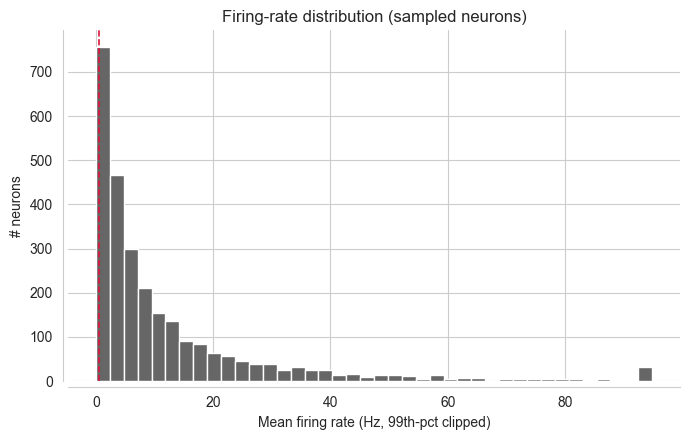

7.1% of 2747 sampled neurons have mean firing rate < 0.5 Hz

Fraction of low-firing-rate neurons by region:
beryl_region
SSp-un     1.0
SSp-bfd    0.7
PB         0.5
PMd        0.5
SSp-n      0.5
          ... 
MOp        0.0
OT         0.0
PAG        0.0
PCN        0.0
void       0.0
Name: mean_fr_hz, Length: 79, dtype: float64


In [ ]:
MIN_FR_HZ = 0.5   # neurons below this are often treated as too sparse to trust for rate-based metrics

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(neuron_sample['mean_fr_hz'].clip(upper=neuron_sample['mean_fr_hz'].quantile(0.99)),
        bins=40, color='0.4', edgecolor='white')
ax.axvline(MIN_FR_HZ, color='crimson', ls='--', lw=1.2)
ax.set_xlabel('Mean firing rate (Hz, 99th-pct clipped)'); ax.set_ylabel('# neurons')
ax.set_title('Firing-rate distribution (sampled neurons)')
sns.despine(ax=ax, offset=4)
plt.tight_layout(); plt.show()

frac_low = (neuron_sample['mean_fr_hz'] < MIN_FR_HZ).mean()
print(f"{frac_low*100:.1f}% of {len(neuron_sample)} sampled neurons have mean firing rate < {MIN_FR_HZ} Hz")

frac_low_by_region = (neuron_sample.dropna(subset=['beryl_region'])
                       .groupby('beryl_region')['mean_fr_hz']
                       .apply(lambda s: (s < MIN_FR_HZ).mean())
                       .sort_values(ascending=False))
print(f"\nFraction of low-firing-rate neurons by region:")
print(frac_low_by_region)